# Import Library & Load Data

In [ ]:
!pip install factor-analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 865.3 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor-analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=f47d9a353f70eecfe70da412f8e0e279442641717738904395ab338e14f7121a
  Stored in directory: /root/.cache/pip/wheels/fa/f7/53/a55a8a56668a6fe0199e0e02b6e0ae3007ec35cdf6e4c25df7
Successfully built factor-analyzer


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Dataset: https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey


In [ ]:
# Load dataset
data = pd.read_csv('survey.csv')

# Lihat 5 data pertama
data.head()


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [ ]:
# cek informasi data (struktur, non-null count, column type)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [ ]:
data.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


# Preprocessing

## Pilih subset kolom yang bermakna

In [ ]:
# pilih kolom tertentu saja yang mungkin lebih bermakna
selected_cols = [
    'Age', 'self_employed', 'family_history', 'work_interfere',
    'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options',
    'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence',
    'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview',
    'phys_health_interview', 'mental_vs_physical', 'obs_consequence'
]

# atur dataframe agar berisi kolom tersebut saja (bisa nama variabel baru)
data = data[selected_cols]
data = data.reset_index(drop=True)
data.head()


,Age,self_employed,family_history,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,NaN,No,Often,6-25,No,Yes,Yes,Not sure,No,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,NaN,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,NaN,No,Rarely,6-25,No,Yes,No,No,No,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,NaN,Yes,Often,26-100,No,Yes,No,Yes,No,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,NaN,No,Never,100-500,Yes,Yes,Yes,No,Don't know,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        1259 non-null   int64 
 1   self_employed              1241 non-null   object
 2   family_history             1259 non-null   object
 3   work_interfere             995 non-null    object
 4   no_employees               1259 non-null   object
 5   remote_work                1259 non-null   object
 6   tech_company               1259 non-null   object
 7   benefits                   1259 non-null   object
 8   care_options               1259 non-null   object
 9   wellness_program           1259 non-null   object
 10  seek_help                  1259 non-null   object
 11  anonymity                  1259 non-null   object
 12  leave                      1259 non-null   object
 13  mental_health_consequence  1259 non-null   object
 14  phys_hea

## Handle missing values & encoding

Lakukan bersih-bersih data dan encoding. Untuk encoding disediakan mapping-an encodingnya agar seragam.

In [ ]:
# missing values dihapus saja
data = data.dropna().reset_index(drop=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 977 entries, 0 to 976
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        977 non-null    int64 
 1   self_employed              977 non-null    object
 2   family_history             977 non-null    object
 3   work_interfere             977 non-null    object
 4   no_employees               977 non-null    object
 5   remote_work                977 non-null    object
 6   tech_company               977 non-null    object
 7   benefits                   977 non-null    object
 8   care_options               977 non-null    object
 9   wellness_program           977 non-null    object
 10  seek_help                  977 non-null    object
 11  anonymity                  977 non-null    object
 12  leave                      977 non-null    object
 13  mental_health_consequence  977 non-null    object
 14  phys_healt

In [ ]:
# cek unique values untuk tiap kolom kategorikal
for col in data.select_dtypes(include=['object']):
    print(f"Unique values in column '{col}':")
    print(data[col].unique())
    print()

Unique values in column 'self_employed':
['Yes' 'No']

Unique values in column 'family_history':
['Yes' 'No']

Unique values in column 'work_interfere':
['Sometimes' 'Never' 'Often' 'Rarely']

Unique values in column 'no_employees':
['1-5' '100-500' '26-100' 'More than 1000' '6-25' '500-1000']

Unique values in column 'remote_work':
['Yes' 'No']

Unique values in column 'tech_company':
['Yes' 'No']

Unique values in column 'benefits':
['Yes' 'No' "Don't know"]

Unique values in column 'care_options':
['Not sure' 'Yes' 'No']

Unique values in column 'wellness_program':
['Yes' 'No' "Don't know"]

Unique values in column 'seek_help':
["Don't know" 'No' 'Yes']

Unique values in column 'anonymity':
['Yes' 'No' "Don't know"]

Unique values in column 'leave':
['Very easy' 'Somewhat difficult' "Don't know" 'Very difficult'
 'Somewhat easy']

Unique values in column 'mental_health_consequence':
['No' 'Maybe' 'Yes']

Unique values in column 'phys_health_consequence':
['No' 'Maybe' 'Yes']

Unique

In [ ]:
# copy dataframe ke dataframe lainnya jika diperlukan
df = data.copy()

In [ ]:
df.columns

Index(['Age', 'self_employed', 'family_history', 'work_interfere',
       'no_employees', 'remote_work', 'tech_company', 'benefits',
       'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence'],
      dtype='object')

In [ ]:
# bersihkan no_employees
employee_order = {
    '1-5': 1,
    '6-25': 2,
    '26-100': 3,
    '100-500': 4,
    '500-1000': 5,
    'More than 1000': 6
}

df['no_employees'] = df['no_employees'].map(employee_order)




In [ ]:
# bersihkan kolom self_employed, isi missing values-nya
# df['self_employed'] = df['self_employed'].fillna(-1)


In [ ]:
# bersihkan work_interfere
interfere_map = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    np.nan: -1  # optional: bisa juga imputasi lain
}

df['work_interfere'] = df['work_interfere'].map(interfere_map)


In [ ]:
# bersihkan kolom ordinal
# kolom leave
leave_map = {
    "Very easy": 0,
    "Somewhat easy": 1,
    "Don't know": 2,
    "Somewhat difficult": 3,
    "Very difficult": 4
}



# kolom coworkers, supervisor
support_map = {
    'No': 0,
    'Some of them': 1,
    'Yes': 2
}

df['leave'] = df['leave'].map(leave_map)
df['coworkers'] = df['coworkers'].map(support_map)
df['supervisor'] = df['supervisor'].map(support_map)





In [ ]:
# bersihkan kolom yang ada value Maybe-nya
maybe_map = {
    'No': 0,
    'Maybe': 1,
    'Yes': 2
}

for col in ['mental_health_consequence', 'phys_health_consequence', 'mental_health_interview', 'phys_health_interview']:
    df[col] = df[col].map(maybe_map)




In [ ]:
# bersihkan kolom yang ada value "Don't know" atau "Not Sure"
dk_map = {
    'No': 0,
    "Don't know": 1,
    "Not sure": 1,
    'Yes': 2
}

for col in ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity','mental_vs_physical']:
    df[col] = df[col].map(dk_map)


In [ ]:
# Bersihkan kolom binary/No Yes
binary_map = {'No': 0, 'Yes': 1}


for col in ['self_employed', 'family_history', 'remote_work', 'tech_company', 'obs_consequence']:
    df[col] = df[col].map(binary_map)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 977 entries, 0 to 976
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Age                        977 non-null    int64
 1   self_employed              977 non-null    int64
 2   family_history             977 non-null    int64
 3   work_interfere             977 non-null    int64
 4   no_employees               977 non-null    int64
 5   remote_work                977 non-null    int64
 6   tech_company               977 non-null    int64
 7   benefits                   977 non-null    int64
 8   care_options               977 non-null    int64
 9   wellness_program           977 non-null    int64
 10  seek_help                  977 non-null    int64
 11  anonymity                  977 non-null    int64
 12  leave                      977 non-null    int64
 13  mental_health_consequence  977 non-null    int64
 14  phys_health_consequence   

## Standardisasi Fitur

In [ ]:
# lakukan scaling/standardisasi

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


# PCA

## Fit PCA dan tampilkan proporsi varian

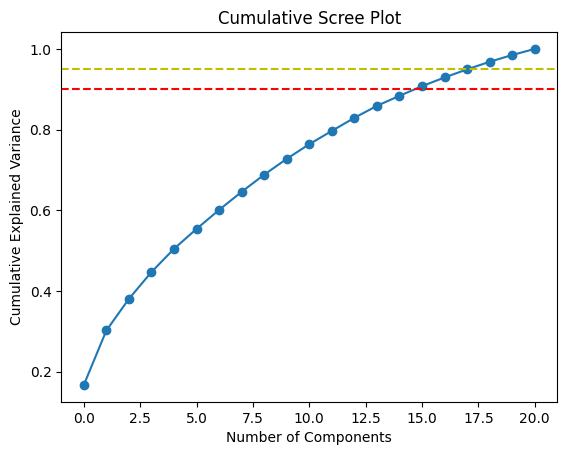

In [ ]:
# Fit PCA dan tampilkan proporsi varian dengan scree plot
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


# Cumulative Scree Plot
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axhline(y=0.95, color='y', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Scree Plot')
plt.show()


Text(0.5, 1.0, 'Scree Plot')

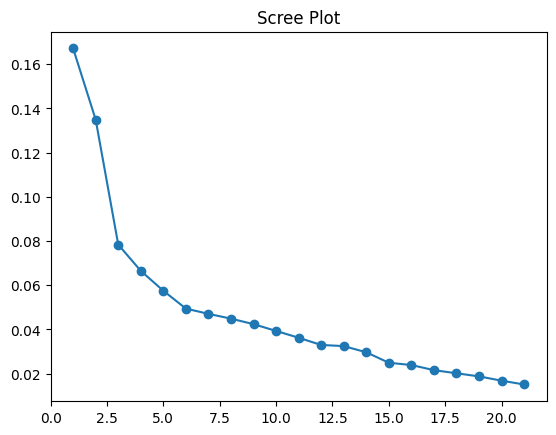

In [ ]:
# Scree Plot
plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o')
plt.title('Scree Plot')

Kira-kira berapa jumlah komponennya?

## Visualisasi

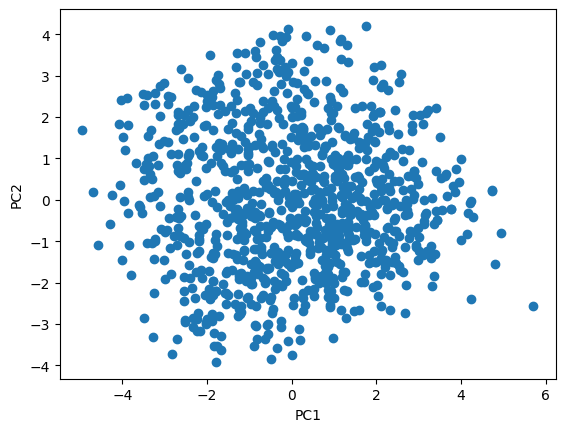

In [ ]:
# buat visualisasi dalam 2D (scatter plot)
# meski komponen yang dipilih pada akhirnya bukan 2, tapi tetap lakukan visualisasi  2D
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

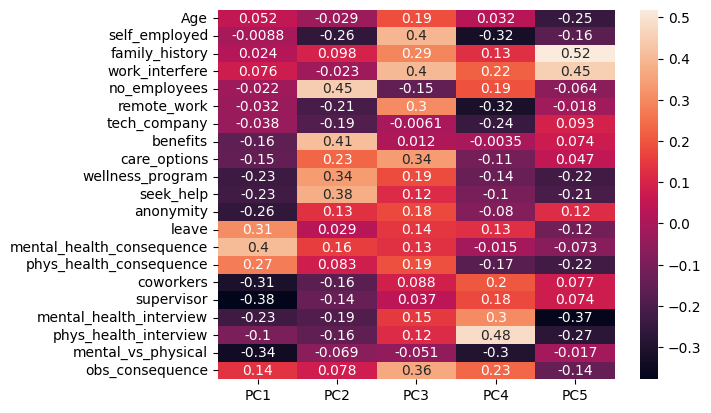

In [ ]:
# buatlah PCA loading heatmap (bisa ambil beberapa komponen pertama)
loadings = pd.DataFrame(
    pca.components_.T[:, :5],
    columns=[f"PC{i+1}" for i in range(5)],
    index=df.columns
)

sns.heatmap(loadings, annot=True)
plt.show()

# Factor Analysis

## Test KMO dan Bartlett

In [ ]:
# Bartlett’s test
_, p_value = calculate_bartlett_sphericity(X_scaled)
print('p-value:', p_value) # jika < 0.05 maka menolak H0, bisa/"cukup" melakukan FA

# KMO test
kmo_all, kmo_model = calculate_kmo(X_scaled)
print('kmo_model:', kmo_model)




p-value: 0.0
kmo_model: 0.7601499884229092


## Cari Jumlah Faktor Optimal (Scree Plot / Eigenvalues)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Text(0.5, 1.0, 'Scree Plot')

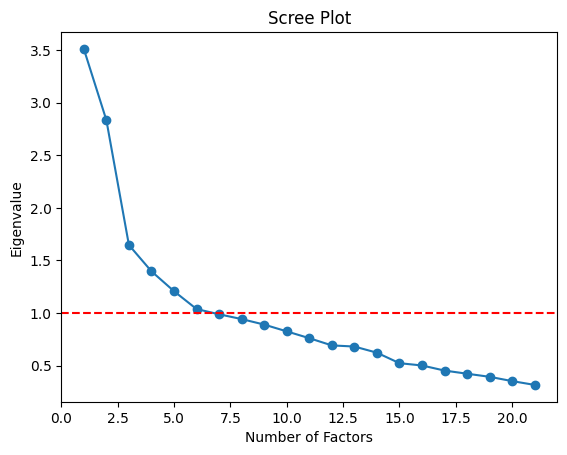

In [ ]:
# fitting dan visualisasikan eigenvalues (scree plot)

fa = FactorAnalyzer()
fa.fit(X_scaled)

ev, v = fa.get_eigenvalues()

# scree plot
plt.plot(range(1, df.shape[1]+1), ev, marker='o')
plt.axhline(y=1, color='r', linestyle='--')
plt.xlabel('Number of Factors')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')




Berdasarkan scree plot, berapa faktor yang dipilih?

## Train Factor Analysis

In [ ]:
# Fit model dan pilih n_factors berdasarkan scree plot sebelumnya

fa = FactorAnalyzer(n_factors=5, rotation='varimax')
fa.fit(X_scaled)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(n_factors=5, rotation='varimax', rotation_kwargs={})

## Interpretasi Loading Matrix

In [ ]:
fa_loadings = pd.DataFrame(
    fa.loadings_,
    columns=[f"F{i+1}" for i in range(5)],
    index=df.columns
)

fa_loadings


,F1,F2,F3,F4,F5
Age,-0.123048,0.003296,0.080743,0.103774,0.035264
self_employed,-0.060432,0.018373,0.690438,0.084980,0.041946
family_history,-0.023785,0.091103,-0.030297,-0.056443,0.377412
work_interfere,-0.072728,-0.037756,0.082274,0.036382,0.522638
no_employees,-0.116437,0.401181,-0.643876,-0.057284,-0.020857
remote_work,0.023513,-0.006622,0.428318,0.044248,0.039642
tech_company,0.119469,-0.120041,0.203472,-0.025356,-0.058125
benefits,0.081539,0.557179,-0.369591,-0.112588,0.068277
care_options,0.063088,0.456161,0.026595,-0.024299,0.222026
wellness_program,0.064491,0.743625,-0.051524,0.023485,-0.050891


In [ ]:
df_fa_loadings = fa_loadings.reset_index()
df_fa_loadings.sort_values(by='F1', ascending=False)

,index,F1,F2,F3,F4,F5
16,supervisor,0.666544,0.105601,0.075768,0.279896,0.083219
15,coworkers,0.536048,0.044917,0.102481,0.289145,0.121508
19,mental_vs_physical,0.493473,0.256204,0.238759,-0.016775,-0.255623
11,anonymity,0.297190,0.374016,0.029091,0.005165,0.113868
17,mental_health_interview,0.230902,0.045775,0.129409,0.697021,-0.103576
6,tech_company,0.119469,-0.120041,0.203472,-0.025356,-0.058125
18,phys_health_interview,0.087588,-0.076350,0.003020,0.508013,0.030754
7,benefits,0.081539,0.557179,-0.369591,-0.112588,0.068277
9,wellness_program,0.064491,0.743625,-0.051524,0.023485,-0.050891
8,care_options,0.063088,0.456161,0.026595,-0.024299,0.222026


In [ ]:
df_fa_loadings.sort_values(by='F3', ascending=False)

,index,F1,F2,F3,F4,F5
1,self_employed,-0.060432,0.018373,0.690438,0.084980,0.041946
5,remote_work,0.023513,-0.006622,0.428318,0.044248,0.039642
19,mental_vs_physical,0.493473,0.256204,0.238759,-0.016775,-0.255623
6,tech_company,0.119469,-0.120041,0.203472,-0.025356,-0.058125
17,mental_health_interview,0.230902,0.045775,0.129409,0.697021,-0.103576
15,coworkers,0.536048,0.044917,0.102481,0.289145,0.121508
3,work_interfere,-0.072728,-0.037756,0.082274,0.036382,0.522638
14,phys_health_consequence,-0.523513,0.009076,0.081476,-0.058764,0.026925
0,Age,-0.123048,0.003296,0.080743,0.103774,0.035264
16,supervisor,0.666544,0.105601,0.075768,0.279896,0.083219


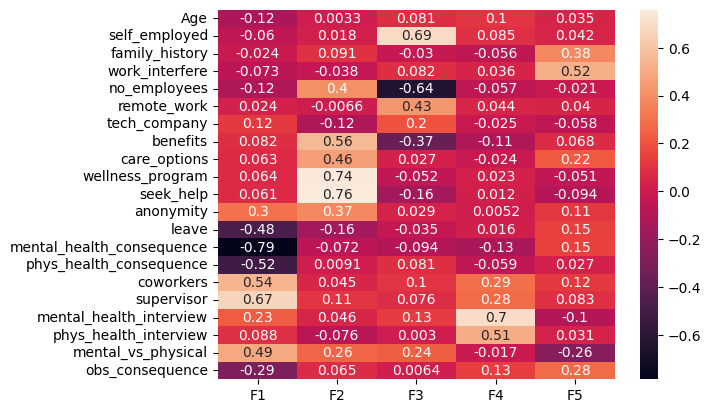

In [ ]:
# buatlah visualisasi factor loadings heatmap

sns.heatmap(fa_loadings, annot=True)
plt.show()